In [1]:
!kaggle datasets download mexwell/silhouettes-for-human-posture-recognition

Dataset URL: https://www.kaggle.com/datasets/mexwell/silhouettes-for-human-posture-recognition
License(s): Attribution 4.0 International (CC BY 4.0)
100% 29.2M/29.2M [00:01<00:00, 18.2MB/s]



In [2]:
import zipfile

In [3]:
zip_path = "/content/silhouettes-for-human-posture-recognition.zip"
extract_path = "/content/posture"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [4]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED=42

In [5]:
import tensorflow as tf

In [6]:
DATASET_DIR = "/content/posture"

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 4800 files belonging to 4 classes.
Using 3840 files for training.
Found 4800 files belonging to 4 classes.
Using 960 files for validation.


In [8]:
class_names = train_ds.class_names

In [9]:
import json

In [10]:
with open('/content/class_names.json','w') as f:
  json.dump(class_names,f,indent=4)

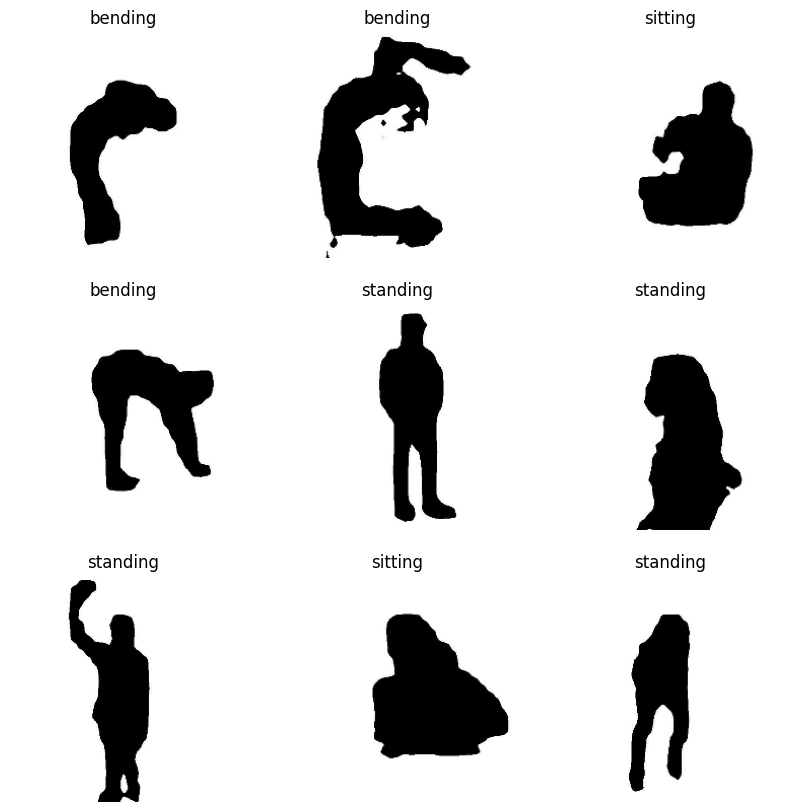

In [12]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.savefig('figures/Sample_images')

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [14]:
from tensorflow.keras import models,layers

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [17]:
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.7060 - loss: 0.7696 - val_accuracy: 0.8500 - val_loss: 0.4143
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.8294 - loss: 0.4726 - val_accuracy: 0.8740 - val_loss: 0.3454
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8469 - loss: 0.4273 - val_accuracy: 0.8292 - val_loss: 0.4164
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8643 - loss: 0.3778 - val_accuracy: 0.8760 - val_loss: 0.3357
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8711 - loss: 0.3513 - val_accuracy: 0.8844 - val_loss: 0.3060
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.8781 - loss: 0.3515 - val_accuracy: 0.9031 - val_loss: 0.2773
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.8766 - loss: 0.3437 - val_accuracy: 0.8802 - val_loss: 0.3125
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.8807 - loss: 0.3309 - v

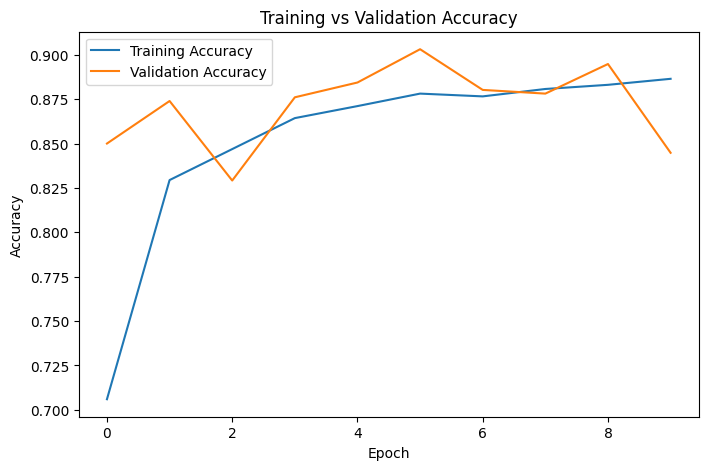

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig('figures/accuracy')
plt.show()

In [22]:
base_model.trainable = True

# Freeze the earlier layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
fine_tune_epochs = 10

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - accuracy: 0.7773 - loss: 0.6304 - val_accuracy: 0.8948 - val_loss: 0.2766
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.8656 - loss: 0.3915 - val_accuracy: 0.8990 - val_loss: 0.2810
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.8784 - loss: 0.3473 - val_accuracy: 0.8969 - val_loss: 0.2953
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.8854 - loss: 0.3241 - val_accuracy: 0.8917 - val_loss: 0.3156
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.8927 - loss: 0.3215 - val_accuracy: 0.8958 - val_loss: 0.3117
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 103ms/step - accuracy: 0.8971 - loss: 0.2934 - val_accuracy: 0.8896 - val_loss: 0.3156
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.9122 - loss: 0.2519 - val_accuracy: 0.8844 - val_loss: 0.3101
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9164 - loss: 0.234

In [26]:
model.save("/content/posture_classifier.h5")